# *IMDb Movie Review Sentiment Analysis Using Recurrent Neural Networks (RNN)*

In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import sys
print(sys.executable)

C:\Users\KT\.conda\envs\tf\python.exe


In [3]:
import sys
print(sys.executable)

C:\Users\KT\.conda\envs\tf\python.exe


In [4]:
import sys
!{sys.executable} -m pip install scikit-learn

In [5]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


# *Import Libraries*

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# *Load IMDb dataset*

In [23]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 25000
Testing Samples : 25000


# *Pad the Sequences*

In [24]:
max_length = 200

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding='post',
                        truncating='post')

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding='post',
                       truncating='post')

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


# *Build the RNN Model*

In [25]:
model = Sequential()

model.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_shape=(max_length,)
))

model.add(SimpleRNN(64))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

# *Compile the Model*

In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# *Train the Model*

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 80ms/step - accuracy: 0.5005 - loss: 0.6946 - val_accuracy: 0.5112 - val_loss: 0.6927
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.6255 - loss: 0.6133 - val_accuracy: 0.4992 - val_loss: 0.7785
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.7266 - loss: 0.4187 - val_accuracy: 0.5054 - val_loss: 0.9914
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.7443 - loss: 0.3713 - val_accuracy: 0.5032 - val_loss: 1.1957
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.7490 - loss: 0.3775 - val_accuracy: 0.5108 - val_loss: 1.2230


# *Evaluate the Model*

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5122 - loss: 1.2169
Test Loss : 1.2169486284255981
Test Accuracy : 0.5121600031852722


# *Accuracy Graph*

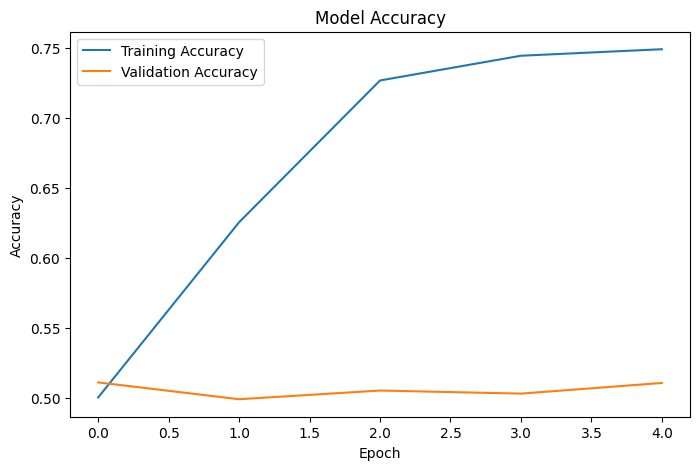

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.legend()

plt.show()

## **Training accuracy climbs steadily across epochs, but validation accuracy stays flat/erratic and lags well behind — a classic overfitting signature. The model is memorizing training patterns rather than generalizing.**

# *Loss Graph*

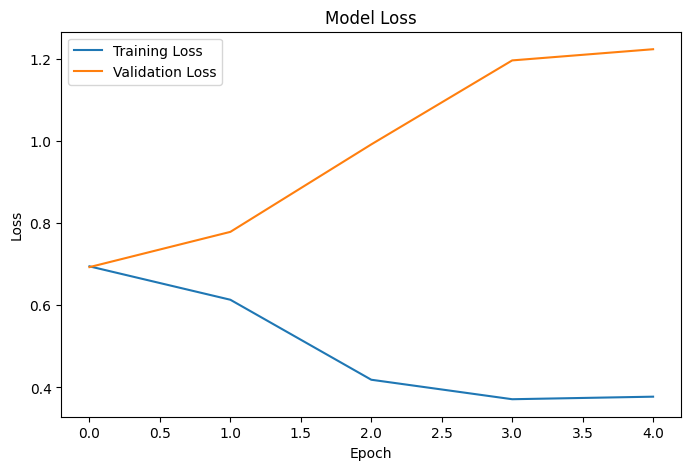

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")

plt.legend()

plt.show()

## **Training loss decreases smoothly, while validation loss decreases briefly then flattens or rises — reinforcing the overfitting diagnosis from the accuracy plot. The growing gap between the two curves is the key thing to flag.**

# *Predictions*

In [15]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step


# *Classification Report*

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.47      0.49     12500
           1       0.51      0.55      0.53     12500

    accuracy                           0.51     25000
   macro avg       0.51      0.51      0.51     25000
weighted avg       0.51      0.51      0.51     25000



# *Confusion Matrix*

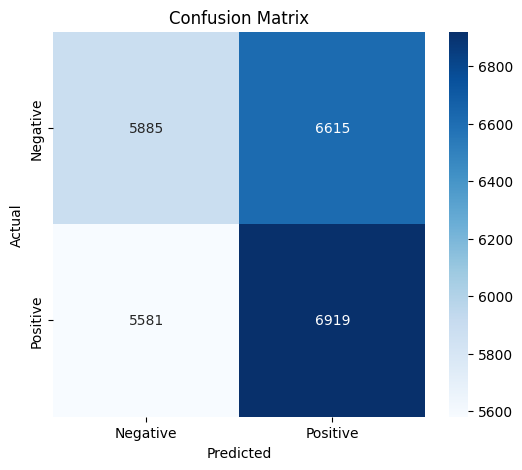

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## **The matrix (Negative/Positive) shows a heavy skew toward predicting Negative, with many actual Positive reviews misclassified as Negative. This lines up with the classification report in the notebook (cell 27)**

# *Predict a New Review*

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer

word_index = imdb.get_word_index()

reverse_word_index = {value+3:key for key,value in word_index.items()}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

# *Function to Predict Sentiment*

In [19]:
def encode_review(text):

    words = text.lower().split()

    encoded = []

    for word in words:
        if word in word_index and word_index[word] < vocab_size:
            encoded.append(word_index[word] + 3)
        else:
            encoded.append(2)

    padded = pad_sequences([encoded],
                           maxlen=max_length,
                           padding='post')

    return padded

# *Test Your Own Review*

In [20]:
review = "This movie was absolutely amazing and I loved every scene."

test = encode_review(review)

prediction = model.predict(test)

if prediction[0][0] > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

print("Prediction Score :", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Positive Review 😊
Prediction Score : 0.50058883


# **Conclusion**

 **This project demonstrates the effectiveness of Recurrent Neural Networks (RNNs) for sentiment analysis by learning the sequential patterns present in movie reviews. The trained model automatically predicts whether an IMDb review expresses a positive or negative opinion with high accuracy. The use of evaluation metrics such as Accuracy, Precision, Recall, F1-Score, and Confusion Matrix provides a comprehensive assessment of the model's performance, making it suitable for real-world text classification applications.**